In [1]:
# ============================================================================
# Environment
#   Python >= 3.10. Install dependencies with:
#       pip install -r requirements.txt
#   Run this notebook from the directory that contains it -- the one holding
#   survey_data/ -- so the relative ./survey_data/ paths below resolve.
# ============================================================================

import sys, os
print("Python:", sys.version.split()[0])
print("Working directory:", os.getcwd())
assert os.path.isdir("./survey_data"), (
    "./survey_data not found. Start Jupyter from the directory that contains "
    "this notebook and survey_data/, then re-run this cell."
)


# Generated figures are written here, not to the notebook's directory.
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

import pandas as pd

all_df=pd.read_csv('./survey_data/moral_moments_data/54827_comments_135_posts.csv')

Python: 3.10.13
Working directory: /Users/ziyuchen/AITA_data_profiling/controversy_certainty


In [2]:
# --- Step 1: Aggregate all_df and df at post level ---

def aggregate_posts(data):
    agg = data.groupby('post_id').apply(lambda g: pd.Series({
        'YA_group': len(g[g['label'].isin(['YTA', 'ESH'])]),
        'NA_group': len(g[g['label'].isin(['NTA', 'NAH'])]),
        'certain_YA': (len(g[(g['label'].isin(['YTA', 'ESH'])) & (g['Certainty'] == 4)]) /
                            max(len(g[g['label'].isin(['YTA', 'ESH'])]), 1)) * 100,
        'certain_NA': (len(g[(g['label'].isin(['NTA', 'NAH'])) & (g['Certainty'] == 4)]) /
                            max(len(g[g['label'].isin(['NTA', 'NAH'])]), 1)) * 100,
    })).reset_index()
    return agg

# agg_all = aggregate_posts(all_df)
agg = aggregate_posts(all_df)
agg['YA_Percentage']=agg['YA_group']/(agg['NA_group']+agg['YA_group'])*100
agg.round(0).sort_values(by='post_id')

/var/folders/79/3xndn_q55w3_h3z4y1m_kp5r0000gn/T/ipykernel_57504/2086618583.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg = data.groupby('post_id').apply(lambda g: pd.Series({


,post_id,YA_group,NA_group,certain_YA,certain_NA,YA_Percentage
0,9uzg28,193.0,281.0,86.0,92.0,41.0
1,a445qb,47.0,27.0,94.0,81.0,64.0
2,ahxy4z,155.0,302.0,51.0,67.0,34.0
3,ajl6q1,111.0,209.0,42.0,79.0,35.0
4,alboqk,186.0,346.0,65.0,38.0,35.0
...,...,...,...,...,...,...
130,ealt06,82.0,41.0,40.0,34.0,67.0
131,eao6dp,170.0,169.0,75.0,82.0,50.0
132,eb5szx,24.0,41.0,29.0,90.0,37.0
133,ecvd73,478.0,4.0,99.0,100.0,99.0


# Profiling

In [3]:
posts_df=pd.read_csv('./survey_data/moral_moments_data/135_posts.csv')
posts_df['controversy_asc']=posts_df['controversy']

/var/folders/79/3xndn_q55w3_h3z4y1m_kp5r0000gn/T/ipykernel_57504/579836771.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


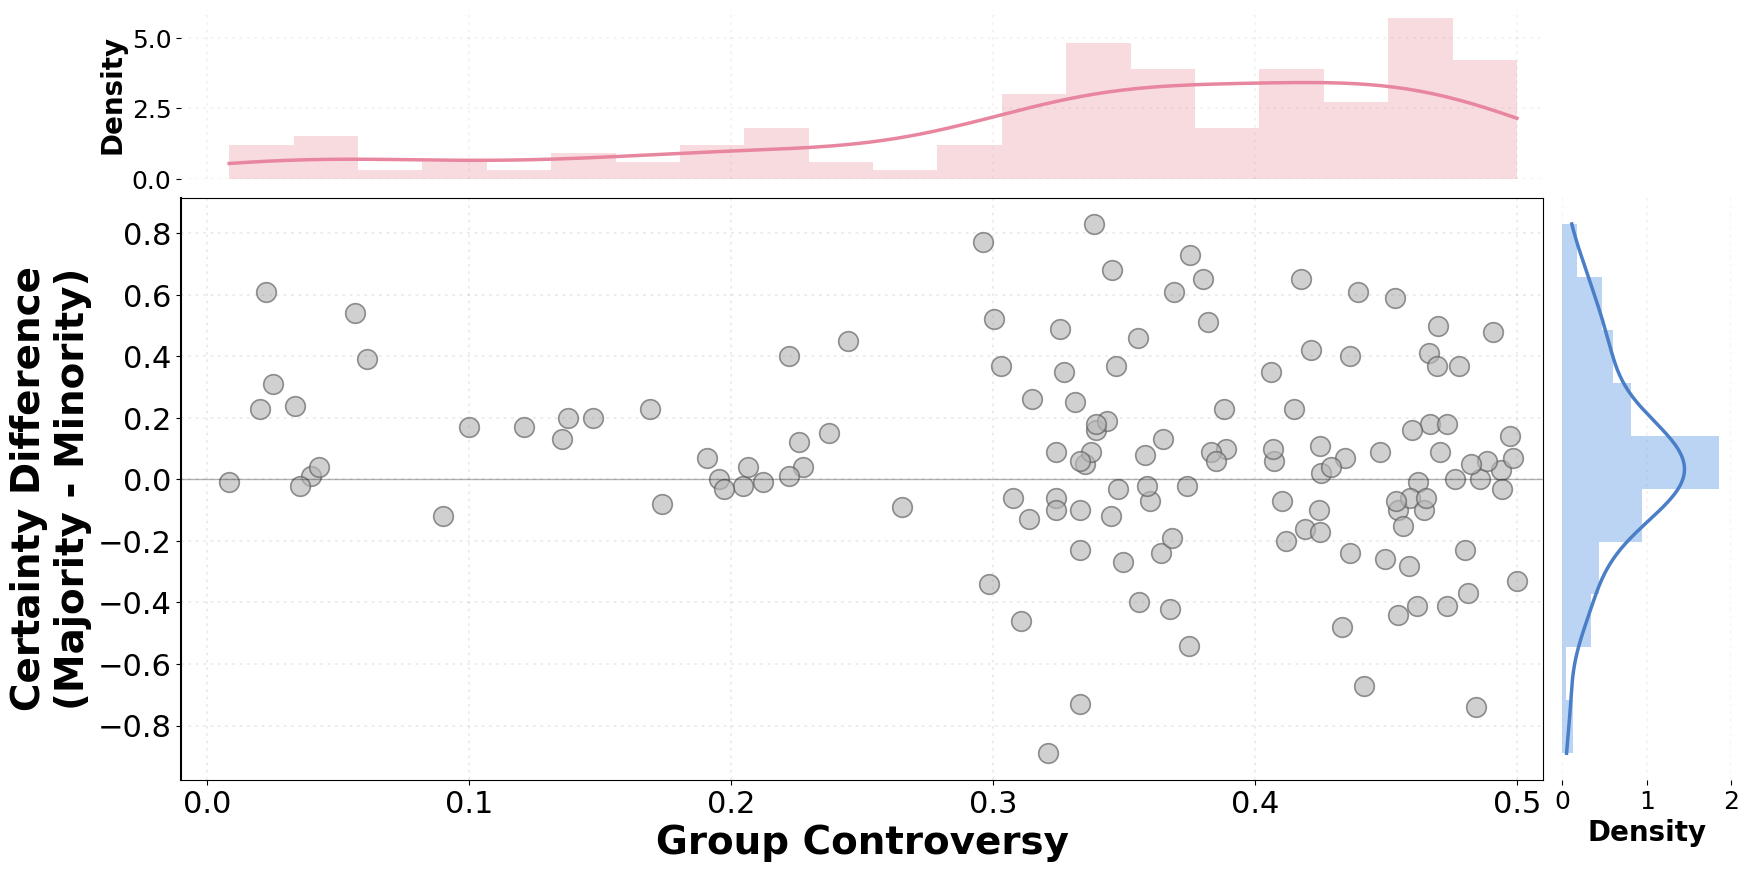

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.ticker as ticker
from scipy import stats
from matplotlib.gridspec import GridSpec

# Calculate 'Certainty_major' and 'Certainty_minor'
posts_df['Certainty_major'] = np.where(
    posts_df['YA_Percentage'] > posts_df['NA_Percentage'], 
    posts_df['certain_YA'] / 100, 
    posts_df['certain_NA'] / 100
)

posts_df['Certainty_minor'] = np.where(
    posts_df['YA_Percentage'] > posts_df['NA_Percentage'], 
    posts_df['certain_NA'] / 100, 
    posts_df['certain_YA'] / 100
)

# Calculate the difference: Majority certainty - Minority certainty
posts_df['Certainty_Diff'] = posts_df['Certainty_major'] - posts_df['Certainty_minor']

# Create figure with GridSpec for layout control
FIG_W, FIG_H = 20, 10

# Both marginal panels are this thick, in inches: the top density plot's height
# equals the right density plot's width. The ratios below are given in inches
# and each list sums to its figure dimension, so a ratio entry *is* that panel's
# size in inches. tight_layout rescales the two directions by different amounts
# (the bold y-label eats more horizontal room than the x-label eats vertical),
# so the equality is re-imposed exactly after the layout pass -- see below.
MARGIN_IN = 2.25

fig = plt.figure(figsize=(FIG_W, FIG_H))
gs = GridSpec(2, 2, figure=fig, hspace=0.05, wspace=0.025,
              height_ratios=[MARGIN_IN, FIG_H - MARGIN_IN],
              width_ratios=[FIG_W - MARGIN_IN, MARGIN_IN])

# Main scatter plot (larger area)
ax_main = fig.add_subplot(gs[1, 0])

# Top density plot for Controversy (x-axis)
ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)

# Right density plot for Certainty_Diff (y-axis)
ax_right = fig.add_subplot(gs[1, 1])

# Scatter plot with aesthetic gray points
scatter = ax_main.scatter(
    posts_df['controversy_asc'], 
    posts_df['Certainty_Diff'], 
    s=200, 
    alpha=0.65, 
    color='#B8B8B8',  # Soft gray
    edgecolors='#5A5A5A',  # Darker gray for edges
    linewidth=1.2,
    label='Individual Posts'
)

# Calculate binned averages for trend line with confidence intervals
posts_df['Controversy_Binned'] = pd.cut(posts_df['controversy_asc'], bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5], precision=2)
posts_df['Controversy_Bin_Label'] = posts_df['Controversy_Binned'].cat.codes

# Group by bin and calculate mean and 95% CI
binned_stats = posts_df.groupby('Controversy_Bin_Label', observed=True).agg({
    'Certainty_Diff': ['mean', 'std', 'count'],
    'controversy_asc': 'mean'
}).reset_index()

binned_stats.columns = ['Bin_Label', 'Certainty_Diff_Mean', 'Certainty_Diff_Std', 'Count', 'Controversy_Mean']

# Calculate 95% confidence intervals
binned_stats['CI_95'] = 1.96 * binned_stats['Certainty_Diff_Std'] / np.sqrt(binned_stats['Count'])

# Sort by controversy value for proper line plotting
binned_stats_sorted = binned_stats.sort_values('Controversy_Mean').reset_index(drop=True)

# Get bin edges
bin_edges = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
bin_centers = binned_stats_sorted['Controversy_Mean'].values

# Create extended x-axis that includes bin edges
x_extended = np.concatenate([[0], bin_centers, [0.5]])
y_extended = np.concatenate([[binned_stats_sorted['Certainty_Diff_Mean'].iloc[0]], 
                              binned_stats_sorted['Certainty_Diff_Mean'].values,
                              [binned_stats_sorted['Certainty_Diff_Mean'].iloc[-1]]])
ci_lower_extended = np.concatenate([[binned_stats_sorted['Certainty_Diff_Mean'].iloc[0] - binned_stats_sorted['CI_95'].iloc[0]], 
                                     binned_stats_sorted['Certainty_Diff_Mean'].values - binned_stats_sorted['CI_95'].values,
                                     [binned_stats_sorted['Certainty_Diff_Mean'].iloc[-1] - binned_stats_sorted['CI_95'].iloc[-1]]])
ci_upper_extended = np.concatenate([[binned_stats_sorted['Certainty_Diff_Mean'].iloc[0] + binned_stats_sorted['CI_95'].iloc[0]], 
                                     binned_stats_sorted['Certainty_Diff_Mean'].values + binned_stats_sorted['CI_95'].values,
                                     [binned_stats_sorted['Certainty_Diff_Mean'].iloc[-1] + binned_stats_sorted['CI_95'].iloc[-1]]])


# Customize main axes
ax_main.set_xlabel('Group Controversy', fontsize=28, fontweight='bold')
ax_main.set_ylabel('Certainty Difference\n(Majority - Minority)', fontsize=28, fontweight='bold')
ax_main.set_xlim(-0.01, 0.51)

# Grid styling for main plot
ax_main.grid(True, which='major', linestyle='--', linewidth=0.33, color='gray', alpha=0.6, dashes=(6, 10))

# Tick spacing for main plot
ax_main.xaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax_main.yaxis.set_major_locator(ticker.MultipleLocator(0.2))

# Tick parameters for main plot
ax_main.tick_params(axis='x', labelsize=22)
ax_main.tick_params(axis='y', labelsize=22)

# Make sure y-axis spine and ticks are visible on the main plot
ax_main.spines['left'].set_visible(True)
ax_main.spines['left'].set_linewidth(1.5)
ax_main.tick_params(axis='y', which='both', left=True, labelleft=True)

# Add horizontal line at y=0 for reference
ax_main.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.3)

# Legend for main plot
# ax_main.legend(fontsize=20, loc='best', title='Legend', title_fontsize=20)

# ===== TOP DENSITY PLOT (Controversy) =====
# Filter data for density estimation
controversy_data = posts_df['controversy_asc'].dropna()

# Plot histogram with KDE for controversy
from scipy.stats import gaussian_kde
kde_x = gaussian_kde(controversy_data)
x_range = np.linspace(controversy_data.min(), controversy_data.max(), 200)

# Add histogram bars
ax_top.hist(controversy_data, bins=20, density=True, alpha=0.6, color='#F4C3CB', edgecolor='none', label='Histogram')
# Overlay KDE line
ax_top.plot(x_range, kde_x(x_range), color='#E8869F', linewidth=2.5, label='KDE')

# Customize top plot - remove borders/spines
ax_top.spines['top'].set_visible(False)
ax_top.spines['right'].set_visible(False)
ax_top.spines['left'].set_visible(False)
ax_top.spines['bottom'].set_visible(False)
ax_top.set_ylabel('Density', fontsize=20, fontweight='bold')
ax_top.tick_params(axis='y', labelsize=18)
ax_top.tick_params(axis='x', bottom=False, top=False, labelbottom=False)
ax_top.grid(True, which='major', linestyle='--', linewidth=0.33, color='gray', alpha=0.4, dashes=(6, 10))
# ax_top.set_title('Certainty Difference across Group Controversy', fontsize=30, fontweight='bold', pad=20)

# ===== RIGHT DENSITY PLOT (Certainty_Diff) =====
# Filter data for density estimation
certainty_diff_data = posts_df['Certainty_Diff'].dropna()

# Plot histogram with KDE for certainty difference
kde_y = gaussian_kde(certainty_diff_data)
y_range = np.linspace(certainty_diff_data.min(), certainty_diff_data.max(), 200)

# Add histogram bars (transposed for horizontal orientation)
ax_right.hist(certainty_diff_data, bins=10, density=True, alpha=0.6, color='#8FB8ED', 
              edgecolor='none', orientation='horizontal', label='Histogram')
# Overlay KDE line
ax_right.plot(kde_y(y_range), y_range, color='#4A7EC6', linewidth=2.5, label='KDE')

# Customize right plot - remove borders/spines
ax_right.spines['top'].set_visible(False)
ax_right.spines['right'].set_visible(False)
ax_right.spines['left'].set_visible(False)
ax_right.spines['bottom'].set_visible(False)

# Customize right plot
ax_right.set_xlabel('Density', fontsize=20, fontweight='bold')
ax_right.tick_params(axis='x', labelsize=18)
# Pinned, not auto: at this panel width the default locator drops the middle
# tick and leaves only 0 and 2.
ax_right.set_xticks([0, 1, 2])
ax_right.tick_params(axis='y', labelleft=False)  # Changed from labelbottom to labelleft
ax_right.set_yticks([])
ax_right.grid(True, which='major', linestyle='--', linewidth=0.33, color='gray', alpha=0.4, dashes=(6, 10))

# Manually sync y-axis limits with main plot
ax_right.set_ylim(ax_main.get_ylim())

# Hide top-right subplot (not needed)
ax_top_right = fig.add_subplot(gs[0, 1])
ax_top_right.axis('off')

plt.tight_layout()

# ===== EQUALISE THE TWO MARGINAL PANELS =====
# tight_layout leaves the top band and the right band slightly unequal, so set
# the right panel's width to the top panel's height (both in inches), keeping
# its right edge and the main/right gutter fixed. The width the right panel
# gives up goes to the scatter, and the top panel follows it (shared x-axis).
p_main, p_top, p_right = (a.get_position() for a in (ax_main, ax_top, ax_right))
gutter = p_right.x0 - p_main.x1

band_w = (p_top.height * FIG_H) / FIG_W       # top panel's height, as a width
ax_right.set_position([p_right.x1 - band_w, p_right.y0, band_w, p_right.height])

main_w = (p_right.x1 - band_w - gutter) - p_main.x0
ax_main.set_position([p_main.x0, p_main.y0, main_w, p_main.height])
ax_top.set_position([p_top.x0, p_top.y0, main_w, p_top.height])

plt.savefig(os.path.join(FIG_DIR, 'fig1c_certainty_diff_vs_controversy.png'), dpi=1000, bbox_inches='tight')
plt.show()

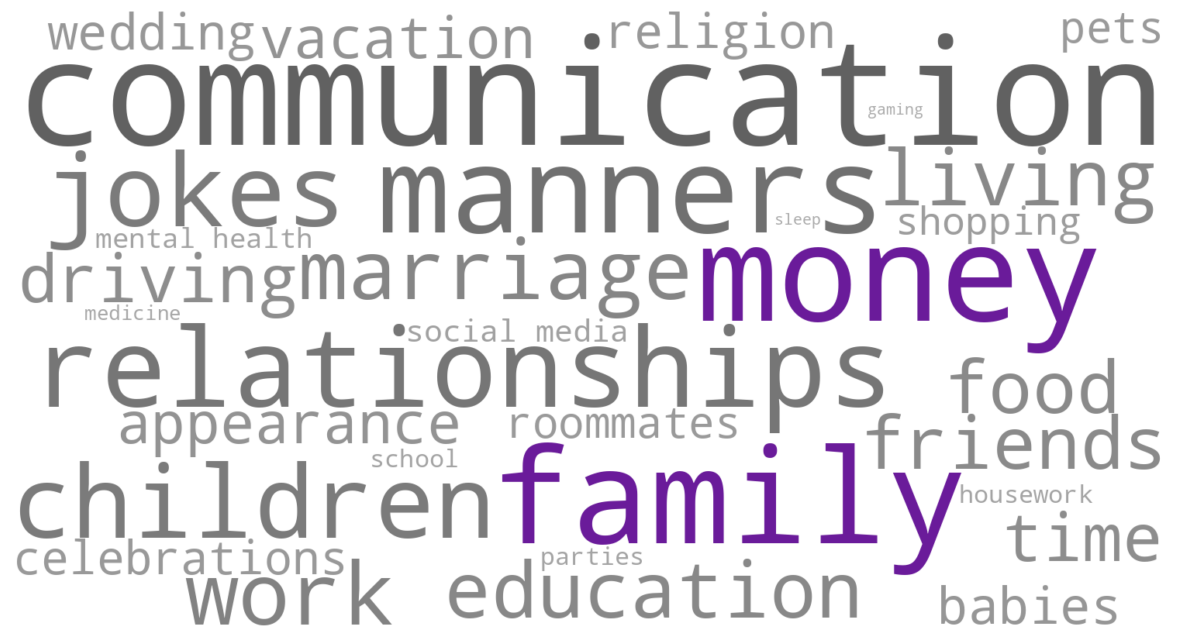

In [5]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine the 'topic_1' and 'topic_2' columns
combined_topics = pd.concat([posts_df['topic_1'], posts_df['topic_2']], ignore_index=True)

# Create a single string with all the keywords
text = ' '.join(combined_topics.dropna())

# Only 'money' and 'family' are drawn in color; every other topic is grey, with
# the shade set by font size so the more frequent topics stay the darker ones.
ACCENT = '#6A1B9A'  # same purple as the topic bar chart above
HIGHLIGHT = {'money': ACCENT, 'family': ACCENT}
MAX_FONT_SIZE = 150

def topic_color(word, font_size, position, orientation, random_state=None, **kwargs):
    if word.lower() in HIGHLIGHT:
        return HIGHLIGHT[word.lower()]
    # largest word ~20% grey, smallest ~70% grey
    frac = min(max(font_size / MAX_FONT_SIZE, 0.0), 1.0)
    level = int(255 * (0.70 - 0.50 * frac))
    return f'rgb({level}, {level}, {level})'

# Generate the word cloud
wordcloud = WordCloud(    width=750,
    height=400,
    background_color='white',
    color_func=topic_color,  # replaces colormap='coolwarm'
    max_font_size=MAX_FONT_SIZE,
    scale=2,
    random_state=42).generate(text)  # fixed so the saved layout is reproducible

# Display the word cloud
plt.figure(figsize=(15, 15))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# Save the word cloud to a high-quality PDF
plt.savefig(os.path.join(FIG_DIR, 'fig1b_topic_wordcloud.png'), format='png', dpi=1000, bbox_inches='tight')
plt.show()
